# MNIST: 2D graph/similarity-based μειωση διαστασης + spectral clustering

Στο notebook αυτο φορτωνω το MNIST και κανω την ιδια εξερευνηση που εκανα στο CIFAR-10:

1. Δουλευω σε **raw pixels** (μετα με HOG).
3. Κανω scaling στα features (StandardScaler) για να εχουν νοημα οι αποστασεις/γειτονιες.
4. Υπολογιζω 2D embedding με μεθοδους που βασιζονται:
   - σε φασματικη αναλυση γραφου (SpectralEmbedding)
   - σε ομοιοτητες/γειτονιες (LPP, LLE, Isomap, t-SNE, KernelPCA)
5. Παιρνω τα 2D δεδομενα και εφαρμοζω **Spectral Clustering**.
6. Οπτικοποιω τις ομαδες με διαφορετικα χρωματα.
7. Κανω εξερευνηση (grid) σε συνδιασμους μεθοδων και παραμετρων και κραταω metrics (ARI/NMI) για συγκριση.

Load libraries

In [1]:
from data_loader import load_mnist
import matplotlib.pyplot as plt
import numpy as np
import time

from sklearn.preprocessing import StandardScaler

# 2D embeddings (graph/similarity based)
from sklearn.manifold import SpectralEmbedding, Isomap, LocallyLinearEmbedding, TSNE
from sklearn.decomposition import KernelPCA

# spectral clustering
from sklearn.cluster import SpectralClustering

from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
from scipy.linalg import eigh
from lpproj import LocalityPreservingProjection

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics.pairwise import pairwise_distances_argmin

# evaluation (unsupervised agreement with true labels)
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

#Hog exploration
from skimage.feature import hog
from skimage.color import rgb2gray

from sklearn.metrics import ConfusionMatrixDisplay


## Load MNIST

In [3]:
mnist = load_mnist(cache_dir="data")

X_train, y_train = mnist["x_train"], mnist["y_train"]
X_test,  y_test  = mnist["x_test"],  mnist["y_test"]
label_names = mnist["label_names"]

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("Num classes:", len(label_names), label_names)


X_train: (60000, 784) y_train: (60000,)
X_test : (10000, 784) y_test : (10000,)
Num classes: 10 ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


## Stratified subset (ισος αριθμος ανα κλαση)

Επειδη οι graph/manifold μεθοδοι δεν ειναι πρακτικες στο πληρες CIFAR-10, παιρνω stratified subset.
Ετσι μπορω να συγκρινω δικαια τις μεθοδους σε ιδια δεδομενα.


In [4]:
def select_stratified_subset(
    X_train_flat, y_train,
    X_test_flat, y_test,
    n_train_per_class, n_test_per_class,
    random_state=0):
    
    num_classes = len(label_names)

    rng = np.random.default_rng(random_state)
    train_indices = []

    for c in range(num_classes):
        class_idxs = np.where(y_train == c)[0]
        if len(class_idxs) < n_train_per_class:
            raise ValueError(
                f"Not enough train samples for class {c}: "
                f"have {len(class_idxs)}, requested {n_train_per_class}"
            )
        chosen = rng.choice(class_idxs, size=n_train_per_class, replace=False)
        train_indices.append(chosen)

    train_indices = np.concatenate(train_indices)
    rng.shuffle(train_indices)

    X_train_sub = X_train_flat[train_indices]
    y_train_sub = y_train[train_indices]

    test_indices = []
    
    for c in range(num_classes):
        class_idxs = np.where(y_test == c)[0]
        if len(class_idxs) < n_test_per_class:
            raise ValueError(
                f"Not enough test samples for class {c}: "
                f"have {len(class_idxs)}, requested {n_test_per_class}"
            )
        chosen = rng.choice(class_idxs, size=n_test_per_class, replace=False)
        test_indices.append(chosen)

    test_indices = np.concatenate(test_indices)
    rng.shuffle(test_indices)

    X_test_sub = X_test_flat[test_indices]
    y_test_sub = y_test[test_indices]

    print("Train shape:", X_train_sub.shape, "Test shape:", X_test_sub.shape)
    return X_train_sub, y_train_sub, X_test_sub, y_test_sub

In [5]:
# experimenting με το μεγεθος
N_TRAIN_PER_CLASS = 200  # 200*10 = 2000
N_TEST_PER_CLASS  = 50

X_train_sub, y_train_sub, X_test_sub, y_test_sub = select_stratified_subset(
    X_train, y_train,
    X_test,  y_test,
    n_train_per_class=N_TRAIN_PER_CLASS,
    n_test_per_class=N_TEST_PER_CLASS,
    random_state=0
)

Train shape: (2000, 784) Test shape: (500, 784)


## Raw pixels -> vector + scaling

Επειδη δεν χρησιμοποιω HOG αυτη τη φορα, δουλευω σε raw pixels.
Κανω flatten καθε εικονα (32x32x3 -> 3072 features) και μετα StandardScaler ωστε οι αποστασεις/γειτονιες να ειναι πιο σταθερες.


In [6]:
# flatten raw pixels
X_flat = X_train_sub.reshape(X_train_sub.shape[0], -1).astype(np.float32)
print("Flat shape:", X_flat.shape)

# scaling
scaler_raw = StandardScaler()
X_flat_s = scaler_raw.fit_transform(X_flat)
print("Scaled flat shape:", X_flat_s.shape)


Flat shape: (2000, 784)
Scaled flat shape: (2000, 784)


## 2D Embeddings (graph/similarity-based)

Οριζω μια ενιαια συναρτηση που επιστρεφει 2D embedding για διαφορετικες μεθοδους:

- **spectral_embedding**: φασματικη αναλυση γραφου (Laplacian eigenmaps)
- **lpp (Locality Preserving Projections)**: γραμμικο graph embedding που διατηρει τοπικες γειτονιες (learned projection απο υψηλη διασταση σε 2D)
- **isomap**: geodesic αποστασεις σε kNN graph
- **lle**: τοπικη γραμμικη ανακατασκευη απο γειτονες
- **tsne**: similarity-based πιθανοτητες γειτονιας + optimization
- **kpca_rbf / kpca_poly**: kernel PCA (similarity via kernel)

Μετα το embedding, ομαδοποιω με spectral clustering στον 2D χωρο.


In [13]:
def compute_embedding_2d(method, X, random_state=0, n_neighbors=15, tsne_perplexity=30):
    method = method.lower()

    if method == "spectral_embedding":
        model = SpectralEmbedding(
            n_components=2,
            affinity="nearest_neighbors",
            n_neighbors=n_neighbors,
            random_state=random_state
        )

    elif method == "isomap":
        model = Isomap(
            n_neighbors=n_neighbors,
            n_components=2
        )

    elif method == "lle":
        model = LocallyLinearEmbedding(
            n_neighbors=n_neighbors,
            n_components=2,
            method="standard",
            random_state=random_state
        )

    elif method == "tsne":
        model = TSNE(
            n_components=2,
            perplexity=tsne_perplexity,
            init="pca",
            learning_rate="auto",
            random_state=random_state
        )

    elif method == "kpca_rbf":
        model = KernelPCA(
            n_components=2,
            kernel="rbf",
            gamma=0.0061
        )

    elif method == "kpca_poly":
        model = KernelPCA(
            n_components=2,
            kernel="poly",
            degree=3,
            gamma=0.0061,
            coef0=1.0
        )
    elif method == "lpp":
        # LPP: Locality Preserving Projections (linear graph-based embedding)
        model = LocalityPreservingProjection(n_components=2)

    else:
        raise ValueError("Unknown method")

    t0 = time.perf_counter()
    Z2 = model.fit_transform(X)
    t = time.perf_counter() - t0
    return Z2, t


In [7]:
def compute_embedding_2d_kpca_tsne(
    X,
    kpca_n=50,
    kpca_kernel="rbf",
    kpca_gamma=None,
    kpca_degree=3,
    kpca_coef0=1.0,
    tsne_perplexity=30,
    random_state=0
):
    """
    X: (N, D) scaled features
    Returns: Z (N, 2), embed_time_sec
    """
    t0 = time.perf_counter()

    kpca = KernelPCA(
        n_components=kpca_n,
        kernel=kpca_kernel,
        gamma=kpca_gamma,
        degree=kpca_degree,
        coef0=kpca_coef0,
        fit_inverse_transform=False
    )
    X_low = kpca.fit_transform(X)

    tsne = TSNE(
        n_components=2,
        perplexity=tsne_perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state
    )
    Z = tsne.fit_transform(X_low)

    return Z, (time.perf_counter() - t0)


## Spectral clustering στα 2D δεδομενα

Μετα το 2D embedding, εφαρμοζω spectral clustering.
Η παραμετρος n_clusters μπορει να αλλαζει για εξερευνηση, αλλα ως baseline βαζω 10 (CIFAR-10).


In [10]:
def spectral_cluster_2d(Z2, n_clusters=10, n_neighbors=15, random_state=0):
    model = SpectralClustering(
        n_clusters=n_clusters,
        affinity="nearest_neighbors",
        n_neighbors=n_neighbors,
        assign_labels="kmeans",
        random_state=random_state
    )
    t0 = time.perf_counter()
    c = model.fit_predict(Z2)
    t = time.perf_counter() - t0
    return c, t


## KPCA στις 50 διαστασεις
Πρωτα ας ριξω στις 50 διαστασεις πριν κανω την εξερευνηση αυτη την φορα

In [15]:
kpca = KernelPCA(
    n_components=50,
    kernel="rbf",
    gamma=None,
    degree=3,
    coef0=1,
    fit_inverse_transform=False
)
X_low = kpca.fit_transform(X_flat_s)
X_low.shape

(2000, 50)

## Εξερευνηση συνδιασμων (embedding + παραμετροι + spectral clustering)

Τρεχω grid σε:
- embedding method
- n_neighbors (για graph-based μεθοδους)
- perplexity (μονο για t-SNE)
- n_clusters (για spectral clustering)

Κραταω:
- χρονο embedding
- χρονο clustering
- ARI / NMI για να εχω αριθμητικη ενδειξη σχεσης με τα labels


In [17]:
methods = ["spectral_embedding", "lpp", "isomap", "lle", "tsne", "kpca_rbf", "kpca_poly"]

neighbors_grid = [5, 10, 15]
clusters_grid  = [8, 9, 10, 11]
tsne_perp_grid = [20, 30, 40]  # only for tsne

results = []

for method in methods:
    for nn in neighbors_grid:
        perp_list = tsne_perp_grid if method == "tsne" else [None]

        for perp in perp_list:
            Z2, t_emb = compute_embedding_2d(
                method,
                X_low,
                random_state=0,
                n_neighbors=nn,
                tsne_perplexity=perp if perp is not None else 30
            )

            for k in clusters_grid:
                c, t_clu = spectral_cluster_2d(Z2, n_clusters=k, n_neighbors=nn, random_state=0)

                ari = adjusted_rand_score(y_train_sub, c)
                nmi = normalized_mutual_info_score(y_train_sub, c)

                results.append({
                    "method": method,
                    "n_neighbors": nn,
                    "tsne_perplexity": perp,
                    "n_clusters": k,
                    "embed_time_sec": t_emb,
                    "cluster_time_sec": t_clu,
                    "ARI": ari,
                    "NMI": nmi
                })

print("Num runs:", len(results))


/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:

Num runs: 108


## Εντοπισμος καλυτερου συνδιασμου

Ταξινομω τα αποτελεσματα (π.χ. με βαση NMI ή ARI) και βρισκω το top-1.
Μετα οπτικοποιω το 2D scatter χρωματισμενο με τα clusters.


In [18]:
# καλυτερο με βαση NMI
best = sorted(results, key=lambda d: d["NMI"], reverse=True)[0]
best


{'method': 'tsne',
 'n_neighbors': 10,
 'tsne_perplexity': 40,
 'n_clusters': 8,
 'embed_time_sec': 4.625321886036545,
 'cluster_time_sec': 0.6708668830106035,
 'ARI': 0.44031882177733084,
 'NMI': np.float64(0.5920771800711759)}

In [19]:
# ξανατρεχω το best για να εχω τα Z2/clusters για plot
best_method = best["method"]
best_nn     = best["n_neighbors"]
best_perp   = best["tsne_perplexity"]
best_k      = best["n_clusters"]

Z2_best, _ = compute_embedding_2d(
    best_method,
    X_flat_s,
    random_state=0,
    n_neighbors=best_nn,
    tsne_perplexity=best_perp if best_perp is not None else 30
)

clusters_best, _ = spectral_cluster_2d(
    Z2_best,
    n_clusters=best_k,
    n_neighbors=best_nn,
    random_state=0
)

print("BEST:", best)
print("Cluster counts:", np.bincount(clusters_best))
best_raw = best

BEST: {'method': 'tsne', 'n_neighbors': 10, 'tsne_perplexity': 40, 'n_clusters': 8, 'embed_time_sec': 4.625321886036545, 'cluster_time_sec': 0.6708668830106035, 'ARI': 0.44031882177733084, 'NMI': np.float64(0.5920771800711759)}
Cluster counts: [449 184 166 221 281 274  53 372]


## Οπτικοποιηση: διαφορετικα χρωματα για τις ομαδες (clusters)

Αυτο ειναι το τελικο ζητουμενο plot: τα 2D δεδομενα μετα το embedding, χρωματισμενα με το αποτελεσμα του spectral clustering.


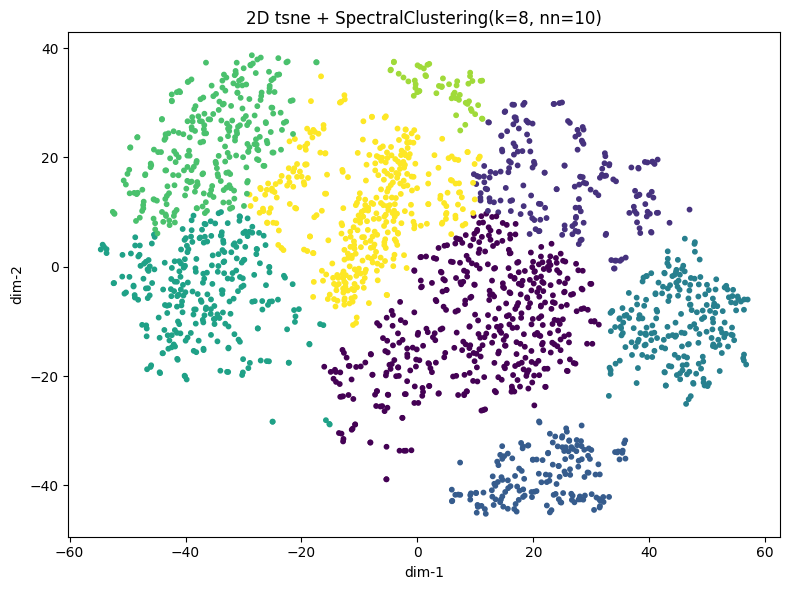

In [20]:
plt.figure(figsize=(8, 6))
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=clusters_best, s=10)
plt.title(f"2D {best_method} + SpectralClustering(k={best_k}, nn={best_nn})")
plt.xlabel("dim-1")
plt.ylabel("dim-2")
plt.tight_layout()
plt.show()


## Συγκριση με true labels

Εδω δεν “εκπαιδευω” κατι με labels. Απλα βλεπω αν οπτικα τα clusters εχουν καποια αντιστοιχια με τις κλασεις του MNIST.


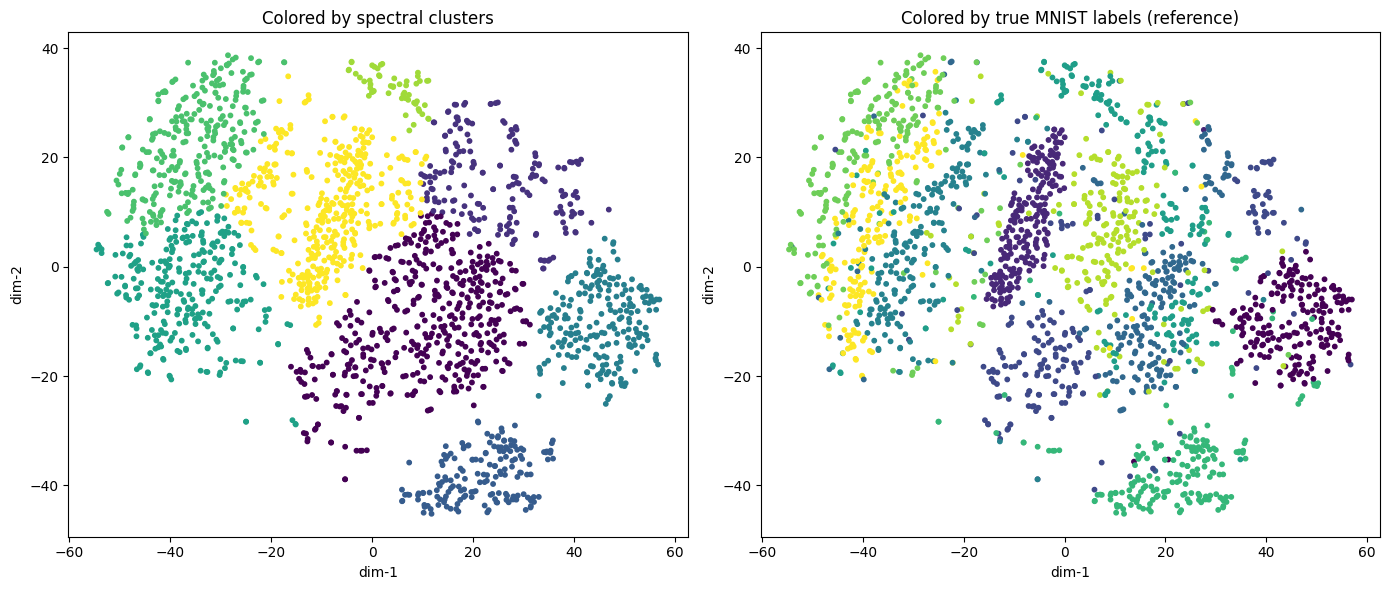

In [21]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=clusters_best, s=10)
plt.title("Colored by spectral clusters")
plt.xlabel("dim-1"); plt.ylabel("dim-2")

plt.subplot(1, 2, 2)
plt.scatter(Z2_best[:, 0], Z2_best[:, 1], c=y_train_sub, s=10)
plt.title("Colored by true MNIST labels (reference)")
plt.xlabel("dim-1"); plt.ylabel("dim-2")

plt.tight_layout()
plt.show()


## Top-3 αποτελεσματα για report

Εμφανιζω τα καλυτερα 3 runs, ωστε να τεκμηριωσω στην αναφορα οτι εκανα εξερευνηση διαφορετικων συνδιασμων (μεθοδοι + παραμετροι).


In [22]:
# top-3 με βαση NMI
topN = sorted(results, key=lambda d: d["NMI"], reverse=True)[:3]
for i, r in enumerate(topN, 1):
    print(i, r)


1 {'method': 'tsne', 'n_neighbors': 10, 'tsne_perplexity': 40, 'n_clusters': 8, 'embed_time_sec': 4.625321886036545, 'cluster_time_sec': 0.6708668830106035, 'ARI': 0.44031882177733084, 'NMI': np.float64(0.5920771800711759)}
2 {'method': 'tsne', 'n_neighbors': 15, 'tsne_perplexity': 20, 'n_clusters': 8, 'embed_time_sec': 3.221322342986241, 'cluster_time_sec': 0.42903532600030303, 'ARI': 0.41276133117019503, 'NMI': np.float64(0.5915698345144773)}
3 {'method': 'tsne', 'n_neighbors': 15, 'tsne_perplexity': 20, 'n_clusters': 10, 'embed_time_sec': 3.221322342986241, 'cluster_time_sec': 0.430937473080121, 'ARI': 0.3869530544398986, 'NMI': np.float64(0.5892397288719062)}


Το 3ο αποτελεσμα εχει σωστο αριθμο απο clusters!

In [23]:
best_k10_from_topN = next((r for r in topN if r.get("n_clusters") == 10), None)
print(best_k10_from_topN)

{'method': 'tsne', 'n_neighbors': 15, 'tsne_perplexity': 20, 'n_clusters': 10, 'embed_time_sec': 3.221322342986241, 'cluster_time_sec': 0.430937473080121, 'ARI': 0.3869530544398986, 'NMI': np.float64(0.5892397288719062)}


In [ ]:
def embed_train_test_2d_kpca_tsne(
    X_train, X_test,
    kpca_n=50,
    kpca_kernel="rbf",
    kpca_gamma=None,
    tsne_perplexity=30,
    random_state=0
):
    X_all = np.vstack([X_train, X_test])
    Z_all, _t = compute_embedding_2d_kpca_tsne(
        X_all,
        kpca_n=kpca_n,
        kpca_kernel=kpca_kernel,
        kpca_gamma=kpca_gamma,
        tsne_perplexity=tsne_perplexity,
        random_state=random_state
    )
    n_train = X_train.shape[0]
    return Z_all[:n_train], Z_all[n_train:]


def compute_centroids(Z_train, clusters_train, n_clusters):
    """Centroid per cluster in 2D embedding space (mean of points)."""
    centroids = np.zeros((n_clusters, Z_train.shape[1]), dtype=np.float32)
    for k in range(n_clusters):
        pts = Z_train[clusters_train == k]
        centroids[k] = pts.mean(axis=0) if len(pts) > 0 else np.array([np.nan, np.nan], dtype=np.float32)
    return centroids


def assign_by_centroid(Z, centroids):
    """
    Assign each point in Z to nearest centroid (Euclidean).
    Handles empty clusters (NaN centroids) by ignoring them.
    """
    valid = ~np.isnan(centroids).any(axis=1)
    cent_valid = centroids[valid]
    idx_valid = np.where(valid)[0]

    # returns indices in cent_valid; map back to original cluster ids
    a = pairwise_distances_argmin(Z, cent_valid)
    return idx_valid[a]


def majority_label_map(clusters_train, y_train, n_clusters):
    """Map each cluster id -> majority MNIST label (using train labels)."""
    m = {}
    for k in range(n_clusters):
        ys = y_train[clusters_train == k]
        m[k] = int(np.bincount(ys).argmax()) if len(ys) > 0 else -1
    return m

In [ ]:
# Build RAW test features using the SAME scaler fitted on train RAW
X_test_flat = X_test_sub.reshape(X_test_sub.shape[0], -1).astype(np.float32)
X_test_flat_s = scaler_raw.transform(X_test_flat)

# best_raw = {
#     "kpca_n": 50,
#     "kpca_kernel": "rbf",
#     "kpca_gamma": None, 
#     "tsne_perplexity": 40,
#     "n_neighbors": 5,
#     "n_clusters": 10
# }

# Embed train+test in same 2D space (transductive for TSNE)
Ztr, Zte = embed_train_test_2d_kpca_tsne(
    X_flat_s,
    X_test_flat_s,
    kpca_n=50,
    kpca_kernel="rbf",
    kpca_gamma=None,
    random_state=0,
    tsne_perplexity=best_k10_from_topN["tsne_perplexity"]
)

# Cluster TRAIN only (this is the "clustering phase")
clusters_tr, _ = spectral_cluster_2d(
    Ztr,
    n_clusters=best_k10_from_topN["n_clusters"],
    n_neighbors=best_k10_from_topN["n_neighbors"],
    random_state=0
)

# Compute centroids from TRAIN clusters
centroids = compute_centroids(Ztr, clusters_tr, best_k10_from_topN["n_clusters"])

# Assign each TEST sample to nearest centroid
clusters_te = assign_by_centroid(Zte, centroids)

print("RAW - test cluster counts:", np.bincount(clusters_te))

# convert clusters -> predicted labels using majority vote from TRAIN
c2y = majority_label_map(clusters_tr, y_train_sub, best_k10_from_topN["n_clusters"])
y_pred = np.array([c2y[c] for c in clusters_te], dtype=int)

acc = accuracy_score(y_test_sub, y_pred)
macro_f1 = f1_score(y_test_sub, y_pred, average="macro")

print(f"RAW centroid-classification on TEST: acc={acc:.4f}, macro_f1={macro_f1:.4f}")
print(classification_report(y_test_sub, y_pred, target_names=label_names))

cm = confusion_matrix(y_test_sub, y_pred)
print("Confusion matrix (rows=true, cols=pred):\n", cm)


/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


RAW - test cluster counts: [ 47 102  28  78  41  71  26  43  12  52]
RAW centroid-classification on TEST: acc=0.5720, macro_f1=0.4946
              precision    recall  f1-score   support

           0       0.91      0.96      0.93        50
           1       0.91      0.98      0.94        50
           2       0.79      0.74      0.76        50
           3       0.00      0.00      0.00        50
           4       0.49      0.76      0.59        50
           5       0.00      0.00      0.00        50
           6       0.79      0.68      0.73        50
           7       0.35      0.86      0.50        50
           8       0.36      0.74      0.49        50
           9       0.00      0.00      0.00        50

    accuracy                           0.57       500
   macro avg       0.46      0.57      0.49       500
weighted avg       0.46      0.57      0.49       500

Confusion matrix (rows=true, cols=pred):
 [[48  0  0  0  0  0  1  1  0  0]
 [ 0 49  1  0  0  0  0  0  0  0]

/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/chpapadopoulos/anaconda3/envs/geoSpy/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

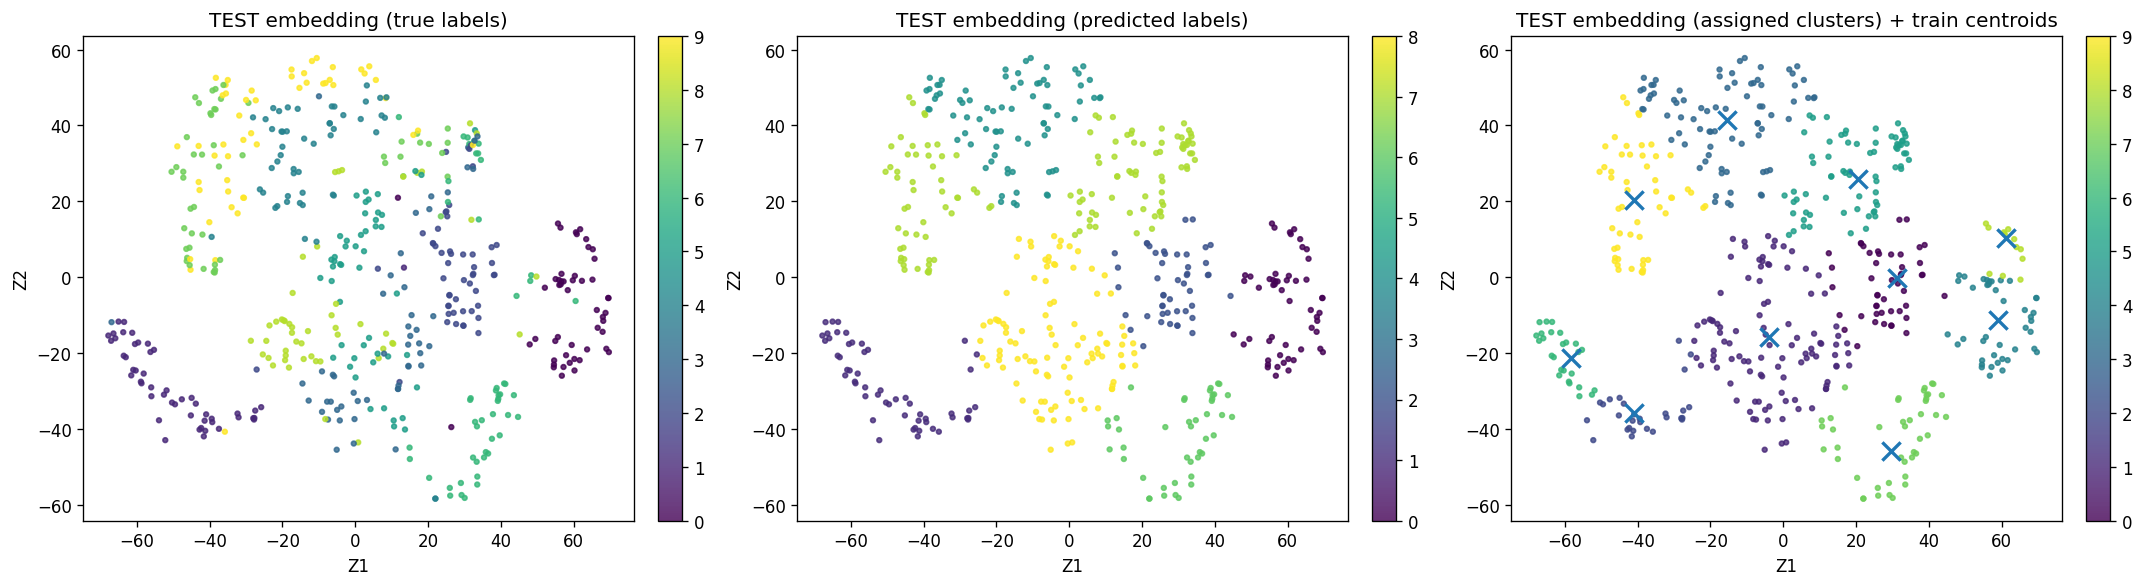

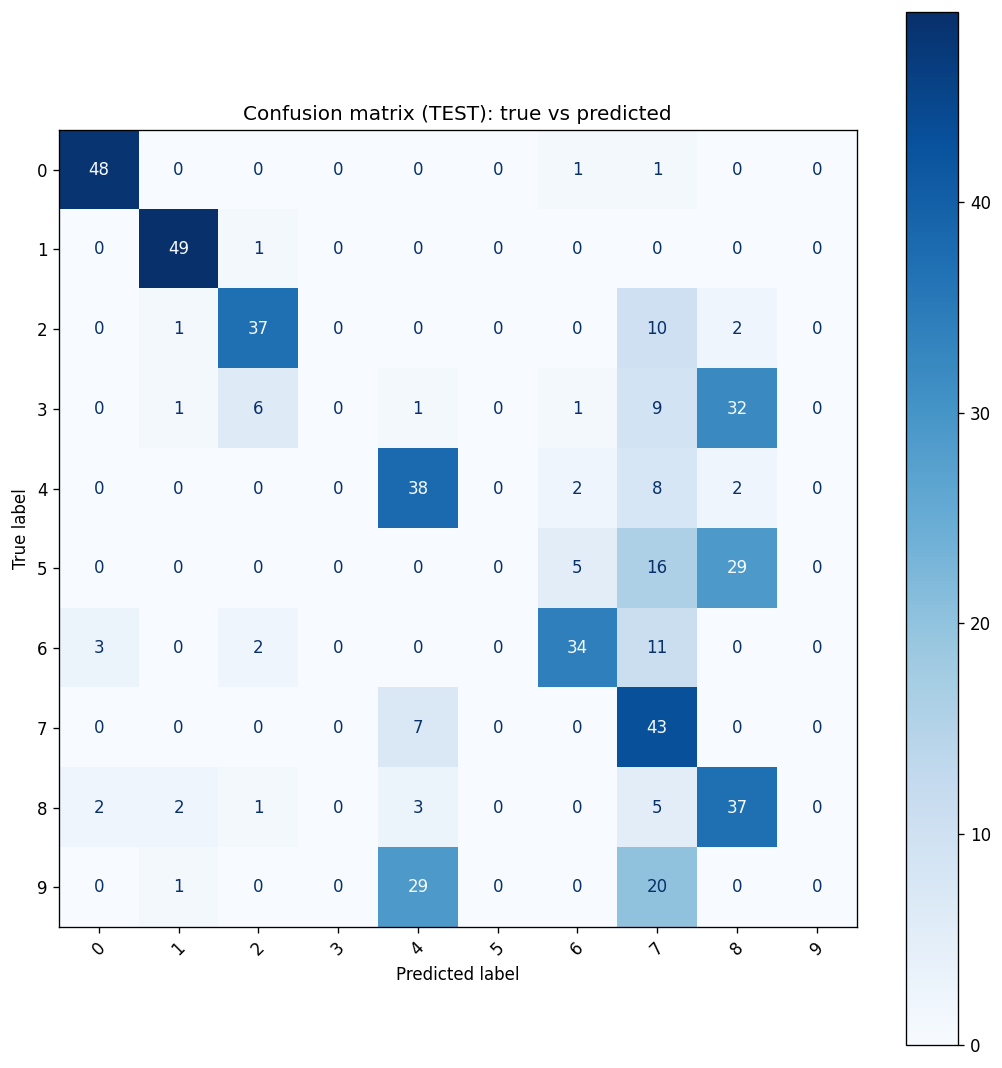

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

# (a) True labels
sc0 = axes[0].scatter(Zte[:, 0], Zte[:, 1], c=y_test_sub, s=8, alpha=0.8)
axes[0].set_title("TEST embedding (true labels)")
axes[0].set_xlabel("Z1")
axes[0].set_ylabel("Z2")
plt.colorbar(sc0, ax=axes[0], fraction=0.046, pad=0.04)

# (b) Predicted labels
sc1 = axes[1].scatter(Zte[:, 0], Zte[:, 1], c=y_pred, s=8, alpha=0.8)
axes[1].set_title("TEST embedding (predicted labels)")
axes[1].set_xlabel("Z1")
axes[1].set_ylabel("Z2")
plt.colorbar(sc1, ax=axes[1], fraction=0.046, pad=0.04)

# (c) Assigned clusters + centroids overlay
sc2 = axes[2].scatter(Zte[:, 0], Zte[:, 1], c=clusters_te, s=8, alpha=0.8)
axes[2].scatter(centroids[:, 0], centroids[:, 1], marker="x", s=120, linewidths=2)
axes[2].set_title("TEST embedding (assigned clusters) + train centroids")
axes[2].set_xlabel("Z1")
axes[2].set_ylabel("Z2")
plt.colorbar(sc2, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# 2) Confusion matrix plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)
fig, ax = plt.subplots(figsize=(9, 9), dpi=120)
disp.plot(ax=ax, cmap="Blues", colorbar=True, xticks_rotation=45)
ax.set_title("Confusion matrix (TEST): true vs predicted")
plt.tight_layout()
plt.show()